# [Umar Jamil's Coding a Multimodal Vision Language Model from Scratch](https://www.youtube.com/watch?v=vAmKB7iPkWw)


From the PaliGemma paper --> " PaliGemma is an open base VLM...model takes as input one or more images, and a textutal description of the teask (the prompt or questoin, which we often refer to as the `prefix`). PaliGemma then autoregressively generates a prediction in the form of a text string (the answer, which we often refer to as the `suffix`). 

* "This simple image+text in, text out API is flexibile enough to cover many standard tasks like:

    - image classification
    - captioning
    - visual question-answering
    - dialogue
    - detection
    - instance segmentation
    - panoptic segmentation
    - depth perception
    - colorization
    - and many more .."

PaliGemma consists of three components:

1. An image encoder, for which we use a publicly available SiGLIP checkpoint, specifically, the 'shape optimized' ViT So400m image encoder. This model was contrastively pre-trained at large scale via sigmoid loss, and has shown state of the art performance, especially for its small size. 
2. A decoder-only language model, for which we use the publically available Gemma-2B v1.0 raw pretrained checkpoints, which strikes a great balance between performance and size. As we will show, this language model model is good enought o match or surpass the performance of VLMs much larger using much larger language models, including previous PaLIs. 
3. A linear layer projecting SigLIP's output tokens into the same dimensions as Gemma-2B's vocab tokens, so they can be concatenated. In early experiments, we found that more complicated alternatives (e.g MLPs) do not provide a clear advantage, and hence decided to use the simpelst option. 

* The Gemma model is a standard decoder-only language model trained on next-token prediction. So given a sequence of tokens, predict the enxt one. It's trained on trillions of tokens of web text, code, and other data, learning to model the probability distribution of what comes next at each position. Same training objective and GPT-2/3/4.


* coding PaliGemma vision encoder, projector, language model, token combinations, and output generation.

* this is a lamguage model that can extract information from images. 

* from our other topic reviews, we know that `PaliGemma` is a unified embedding decoder architecture where visual tokens get projected and concatenated with text tokens and all are fed into a single decoder. 

* also called conditional generation

### Topics

1. Vision Transformer 
2. Contrastive LEarning (CLIP and SigLip)
3. Language Model (Gemma)
4. KV-Cache
5. Rotary Positional Embedding
6. Normalization (Batch, Layer, and RMS)


* Finally, we can fine-tune our own PaliGemma following [this tutorial](https://huggingface.co/blog/paligemma)

### Diving into Visual Encoder (contrastive)

* This is the CLIP part of our notebooks. 

#### What is contrastive learning?

* get a [NxN] similarity matrix od image-text pairs. We encode the text and the image, then do cosine similaorty of their emebeddings and expect pairs to end up with high similarity and all other with lower similarity.

* an embedding is a vector that captures the essence of the text or the image. 

* image-description dataset. 

* 

The expected, contrastive trained similaoirty matrix should look like the followins, where each row is an image each column is a text caption, and the values in the cells are the cosine similarity of the pairs. Dot product of an aimge with a text that doesnt corepsond to that image, it should produce a low value. 

We need to find a dot product that gives us a similarity matrix like the below. 

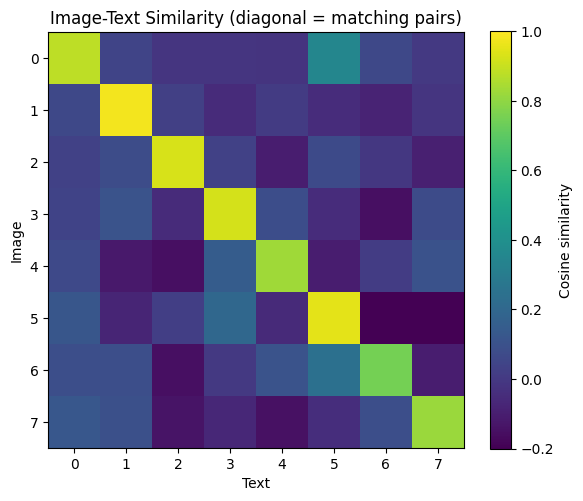

In [2]:
import torch                                                                                                                                                  
import matplotlib.pyplot as plt                                                                                                                             
                                                                                                                                                            
N = 8                                                                                                                                                         
# Start with small random values, add identity to boost diagonal                                                                                              
sim_matrix = torch.randn(N, N) * 0.1 + torch.eye(N) * 0.8                                                                                                     
                                                                                                                                                            
plt.figure(figsize=(6, 5))                                                                                                                                    
plt.imshow(sim_matrix, cmap='viridis', vmin=-0.2, vmax=1.0)                                                                                                   
plt.colorbar(label='Cosine similarity')                                                                                                                       
plt.xlabel("Text")
plt.ylabel("Image")                                                                                                                                           
plt.title("Image-Text Similarity (diagonal = matching pairs)")                                                                                                
plt.tight_layout()                                                                                                                                            
plt.show()

We use cross-entropy loss to achieve this. If we have a sample similarity matrix before training and after training, we can see how the loss is very different. And this loss will help us achieve the results we want. 


* The labels are simply the diagonal. `labels = torch.arange(logits.shape[0], device=logits.device)`

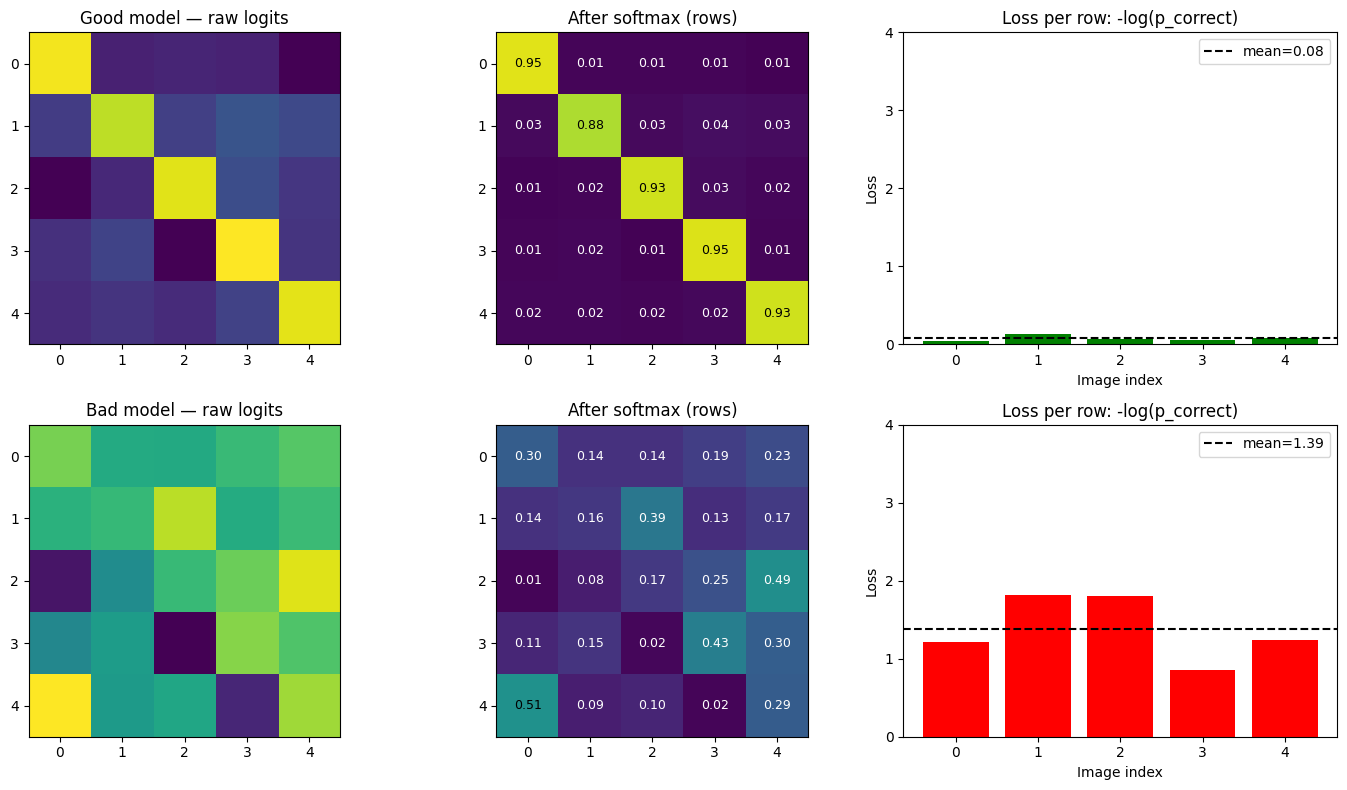

In [10]:
import torch                                                                                                                                                  
import torch.nn.functional as F  
import torch.nn as nn                                                                                                                           
import matplotlib.pyplot as plt                                                                                                                               
                                                                                                                                                            
# Simulate a 5x5 similarity matrix (logits) — like CLIP produces                                                                                              
# Good model: diagonal is highest                                                                                                                           
logits_good = torch.eye(5) * 4.0 + torch.randn(5, 5) * 0.3                                                                                                    
# Bad model: random, no structure                                                                                                                             
logits_bad = torch.randn(5, 5)                                                                                                                                
                                                                                                                                                            
labels = torch.arange(5)  # correct match: image i → text i                                                                                                   
                                                                                                                                                            
# Cross-entropy converts logits → softmax probabilities, then penalizes                                                                                       
# based on how much probability lands on the correct label                                                                                                  
                                                                                                                                                            
fig, axes = plt.subplots(2, 3, figsize=(14, 8))                                                                                                               
                                                                                                                                                            
for i, (logits, name) in enumerate([(logits_good, "Good model"), (logits_bad, "Bad model")]):                                                                 
    # Raw logits                                                                                                                                            
    axes[i, 0].imshow(logits, cmap='viridis')                                                                                                                 
    axes[i, 0].set_title(f"{name} — raw logits")                                                                                                              

    # After softmax (per row) — this is what cross-entropy does internally                                                                                    
    probs = F.softmax(logits, dim=-1)                                                                                                                       
    axes[i, 1].imshow(probs, cmap='viridis', vmin=0, vmax=1)                                                                                                  
    axes[i, 1].set_title(f"After softmax (rows)")                                                                                                             
    # Annotate probabilities                                                                                                                                  
    for r in range(5):                                                                                                                                        
        for c in range(5):                                                                                                                                    
            color = 'white' if probs[r, c] < 0.5 else 'black'                                                                                                 
            axes[i, 1].text(c, r, f"{probs[r, c]:.2f}", ha='center', va='center', color=color, fontsize=9)                                                    
                                                                                                                                                            
    # Per-row loss: -log(probability of correct class)                                                                                                        
    row_losses = [-torch.log(probs[r, labels[r]]).item() for r in range(5)]                                                                                   
    axes[i, 2].bar(range(5), row_losses, color=['green' if l < 0.5 else 'red' for l in row_losses])                                                           
    axes[i, 2].set_title(f"Loss per row: -log(p_correct)")                                                                                                    
    axes[i, 2].set_ylabel("Loss")                                                                                                                             
    axes[i, 2].set_xlabel("Image index")                                                                                                                      
                                                                                                                                                            
    loss = F.cross_entropy(logits, labels)                                                                                                                    
    axes[i, 2].axhline(y=loss.item(), color='black', linestyle='--', label=f"mean={loss.item():.2f}")                                                       
    axes[i, 2].legend()                                                                                                                                       
                                                                                                                                                            
for ax in axes.flat:                                                                                                                                          
    ax.set_xticks(range(5))                                                                                                                                 
    ax.set_yticks(range(5))                                                                                                                                   
                                                                                                                                                            
plt.tight_layout()                                                                                                                                            
plt.show()

### What are some problems with CLIP?

* cross-entropy loss. We compute logits that are transformed into a distribution. 
* softmax function takes logits and converts into distribution. 
* take the ouput of the model, we exponentiate it, and then divide by the sum of all the items. 
* need for each row, the exponentials of the items, then divide by the sum of the exponential of all the items.
* exponential function grows very fast. Since we use a fixed represnetation like 32-bit, this might become a problem. if exponential is too big, then it might not be represented well and we need to add **numerical stability**
* pytorch uses the normalization constant, so it takes care of that issue for us. PyTorch's F.cross_entropy uses the log-sum-exp trick internally (subtract the max first)
* This is also why **SigLIP replaces the softmax with a sigmoid**. They signmoid each pair independently. It also helps us parallelize so that we dont need the entire row or column across devices. Should help us increase batch size too. 
* With SigLIP, we take the similarity matrix [NxN] with all the dot products. Instead of trying to maximize the values across the diagonal, we use a kind of binary classifier using sigmoid loss. 
* each dot product is independent of each other. Every row then has one 'true ground truth' value across the diagonal and everything else is a 'wrong classification'.
* each dot product is run through a signmoid and force labels to be 1 for true diagonal and everything is wrong. No more normalization constant nor maximum values.

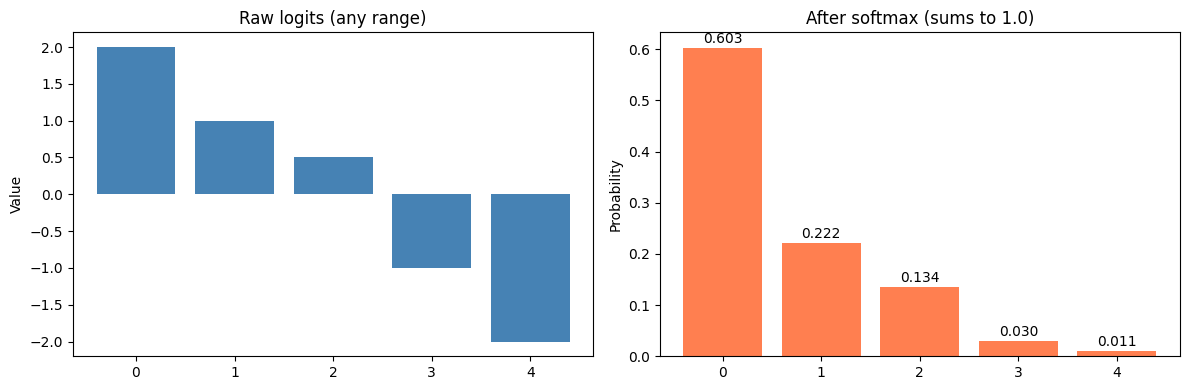

Softmax step by step:
  logits:      [2.0, 1.0, 0.5, -1.0, -2.0]
  exp(logits): [7.389056205749512, 2.7182817459106445, 1.6487212181091309, 0.3678794503211975, 0.1353352814912796]
  sum of exp:  12.2593
  softmax:     [0.6027319431304932, 0.22173269093036652, 0.13448767364025116, 0.030008256435394287, 0.01103942096233368]
  sum:         1.0000


In [4]:
## How does softmax work again?

logits = torch.tensor([2.0, 1.0, 0.5, -1.0, -2.0])                                                                                                          
                                                                                                                                                            
# Softmax: exp(each) / sum(exp(all)) → probabilities that sum to 1                                                                                            
probs = F.softmax(logits, dim=-1)                                                                                                                             
                                                                                                                                                            
fig, axes = plt.subplots(1, 2, figsize=(12, 4))                                                                                                               

axes[0].bar(range(5), logits, color='steelblue')                                                                                                              
axes[0].set_title("Raw logits (any range)")                                                                                                                 
axes[0].set_ylabel("Value")                                                                                                                                   
                                                                                                                                                            
axes[1].bar(range(5), probs, color='coral')                                                                                                                   
axes[1].set_title("After softmax (sums to 1.0)")                                                                                                            
axes[1].set_ylabel("Probability")                                                                                                                             
for i, p in enumerate(probs):                                                                                                                               
    axes[1].text(i, p + 0.01, f"{p:.3f}", ha='center', fontsize=10)                                                                                           
                                                                                                                                                            
plt.tight_layout()                                                                                                                                            
plt.show()                                                                                                                                                    
                                                                                                                                                            
# Show the math explicitly                                                                                                                                    
print("Softmax step by step:")                                                                                                                                
print(f"  logits:      {logits.tolist()}")                                                                                                                    
print(f"  exp(logits): {torch.exp(logits).tolist()}")                                                                                                         
print(f"  sum of exp:  {torch.exp(logits).sum().item():.4f}")                                                                                                 
print(f"  softmax:     {probs.tolist()}")                                                                                                                     
print(f"  sum:         {probs.sum().item():.4f}") 

CLIP loss (softmax CE):     0.5566
SigLIP loss (sigmoid BCE):  0.6162


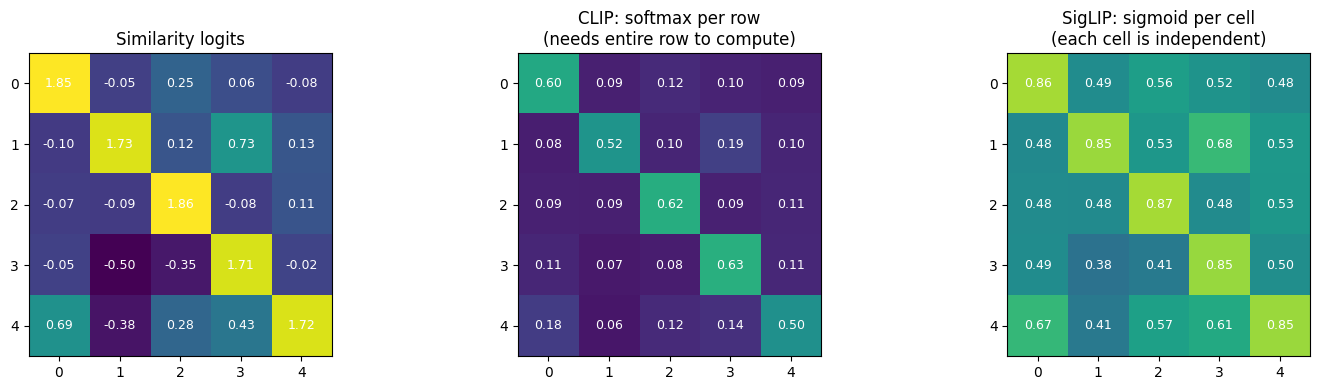

=== Why SigLIP scales better ===

CLIP softmax for cell (2,3):
  needs: exp(logit[2,3]) / (exp(logit[2,0]) + exp(logit[2,1]) + ... + exp(logit[2,N]))
  → must have ALL logits in row 2 on the SAME device

SigLIP sigmoid for cell (2,3):
  needs: sigmoid(logit[2,3]) = 1 / (1 + exp(-logit[2,3]))
  → only needs THIS ONE value, can be on ANY device


In [5]:
N = 5                                                                                                                                                         
# Fake similarity matrix (logits)                                                                                                                           
logits = torch.randn(N, N) * 0.3 + torch.eye(N) * 2.0                                                                                                         
                                                                                                                                                            
# === CLIP loss: softmax cross-entropy (global normalization) ===                                                                                             
labels_clip = torch.arange(N)                                                                                                                                 
clip_loss_i = F.cross_entropy(logits, labels_clip)                                                                                                            
clip_loss_t = F.cross_entropy(logits.T, labels_clip)                                                                                                          
clip_loss = (clip_loss_i + clip_loss_t) / 2                                                                                                                   
                                                                                                                                                            
# === SigLIP loss: sigmoid binary cross-entropy (per-pair, independent) ===                                                                                   
# Labels: +1 on diagonal (match), -1 off diagonal (no match)                                                                                                  
labels_sig = 2 * torch.eye(N) - 1  # +1 for match, -1 for mismatch                                                                                            
                                                                                                                                                            
# Each pair independently: sigmoid(-label * logit)                                                                                                            
# This pushes matching pairs toward +inf and non-matching toward -inf                                                                                         
siglip_loss = -F.logsigmoid(labels_sig * logits).mean()                                                                                                       
                                                                                                                                                            
print(f"CLIP loss (softmax CE):     {clip_loss.item():.4f}")                                                                                                  
print(f"SigLIP loss (sigmoid BCE):  {siglip_loss.item():.4f}")                                                                                                
                                                                                                                                                            
# Visualize the difference                                                                                                                                    
fig, axes = plt.subplots(1, 3, figsize=(15, 4))                                                                                                               
                                                                                                                                                            
# Raw logits    
axes[0].imshow(logits, cmap='viridis')
axes[0].set_title("Similarity logits")
for r in range(N):                                                                                                                                            
    for c in range(N):                                                                                                                                        
        axes[0].text(c, r, f"{logits[r,c]:.2f}", ha='center', va='center', color='white', fontsize=9)                                                         
                                                                                                                                                            
# CLIP: softmax probabilities (each row sums to 1 — needs full row)                                                                                           
clip_probs = F.softmax(logits, dim=-1)                                                                                                                        
axes[1].imshow(clip_probs, cmap='viridis', vmin=0, vmax=1)                                                                                                    
axes[1].set_title("CLIP: softmax per row\n(needs entire row to compute)")
for r in range(N):                                                                                                                                            
    for c in range(N):
        axes[1].text(c, r, f"{clip_probs[r,c]:.2f}", ha='center', va='center', color='white', fontsize=9)                                                     
                                                                                                                                                            
# SigLIP: sigmoid per cell (independent, no normalization)                                                                                                    
sig_probs = torch.sigmoid(logits)                                                                                                                             
axes[2].imshow(sig_probs, cmap='viridis', vmin=0, vmax=1)                                                                                                     
axes[2].set_title("SigLIP: sigmoid per cell\n(each cell is independent)")                                                                                     
for r in range(N):                                                                                                                                            
    for c in range(N):                                                                                                                                        
        axes[2].text(c, r, f"{sig_probs[r,c]:.2f}", ha='center', va='center', color='white', fontsize=9)                                                      
                                                                                                                                                            
plt.tight_layout()                                                                                                                                            
plt.show()                                                                                                                                                    
                                                                                                                                                            
# Show WHY independence matters for parallelism                                                                                                               
print("=== Why SigLIP scales better ===\n")                                                                                                                   
print("CLIP softmax for cell (2,3):")                                                                                                                         
print(f"  needs: exp(logit[2,3]) / (exp(logit[2,0]) + exp(logit[2,1]) + ... + exp(logit[2,N]))")                                                              
print(f"  → must have ALL logits in row 2 on the SAME device\n")                                                                                              
                                                                                                                                                            
print("SigLIP sigmoid for cell (2,3):")                                                                                                                       
print(f"  needs: sigmoid(logit[2,3]) = 1 / (1 + exp(-logit[2,3]))")                                                                                           
print(f"  → only needs THIS ONE value, can be on ANY device") 

ok, but why contrastive? 

    - So we can align text to images. 
    - we want embeddings to be contrsated with text (a text prompt)
    - vision encoder to be used with text. 
    - data is relatively easy to find since images usually have some kind of caption. 


## Digging into the Vision Encoder

* a sequence to sequence model. 
* feeding it a sequence of patches and it returns a sequence of embeddings
* split image into 16x16 patches

```
Input Image (e.g., 224×224×3)
          │
          ▼
  ┌─────────────────┐
  │  Split into      │   224/16 = 14×14 = 196 patches
  │  Patches (16×16) │
  └────────┬────────┘
           ▼
  ┌─────────────────┐
  │  Linear Project  │   each patch → 768-d vector (or Conv2d)
  │  (Patch Embed)   │
  └────────┬────────┘
           ▼
    [CLS] + 196 patch tokens          ← prepend CLS token
           +
    positional embeddings              ← add learned pos embeddings
           │
           ▼
  ┌─────────────────────────────┐
  │  Transformer Block ×12       │
  │  ┌─────────────────────┐    │
  │  │ LayerNorm            │    │
  │  │ Multi-Head Attention │    │  (bidirectional, no mask)
  │  │ + Residual           │    │
  │  ├─────────────────────┤    │
  │  │ LayerNorm            │    │
  │  │ FFN (Linear→GELU→   │    │
  │  │      Linear)         │    │
  │  │ + Residual           │    │
  │  └─────────────────────┘    │
  └──────────┬──────────────────┘
             ▼
      Take CLS token (position 0)
             │
             ▼
  ┌─────────────────┐
  │  LayerNorm       │
  │  Linear → logits │   (classification head)
  └─────────────────┘
             │
             ▼
       Class prediction
```

* go from a grid of patches, to a flattened vector of embeddings so we loose positional information. 
* we add positional encoding (learned) and we just add those to the grid. They are learned (not using sinusoidal function)
* 

Patch embeddings shape: torch.Size([1, 16, 8])
These have NO position info — the model doesn't know patch 0 is top-left

Positional embeddings shape: torch.Size([1, 16, 8])
After adding: torch.Size([1, 16, 8])


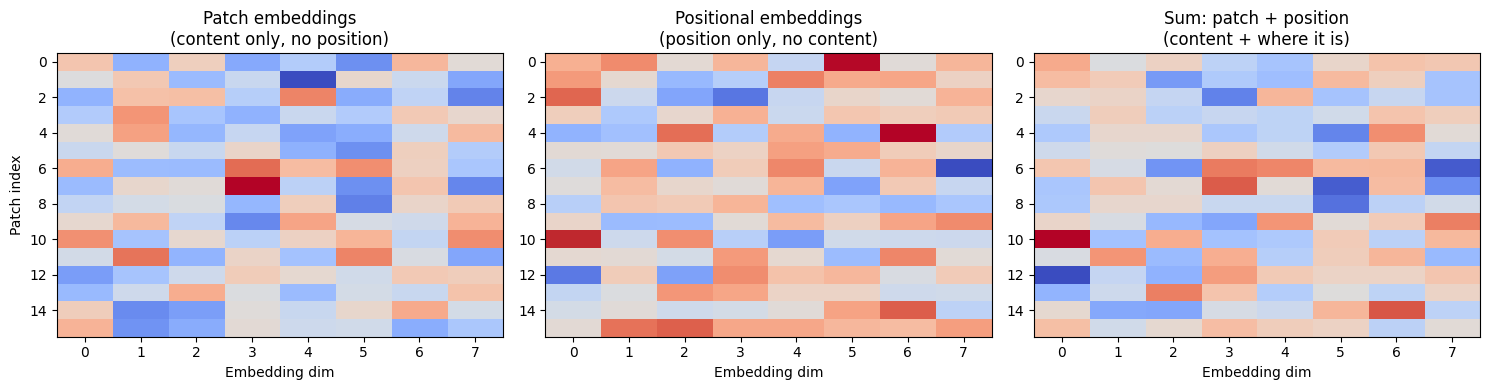

Without pos emb — model can't tell these apart:
  Original patches sum: 12.3635
  Shuffled patches sum: 12.3635
  (same patches, different order, but attention treats them identically)

With pos emb — shuffled version is completely different:
  Difference norm: 17.5148


In [ ]:
# Simulate: 1 image, 4x4 = 16 patches, each embedded to 8 dims
num_patches = 16
embed_dim = 8

# Step 1: Patch embeddings (from Conv2d or linear projection)
patch_embs = torch.randn(1, num_patches, embed_dim)
print(f"Patch embeddings shape: {patch_embs.shape}")
print(f"These have NO position info — the model doesn't know patch 0 is top-left")

# Step 2: Learned positional embeddings (one vector per position)
pos_embedding = torch.randn(1, num_patches, embed_dim)
print(f"\nPositional embeddings shape: {pos_embedding.shape}")

# Step 3: Just add them
x = patch_embs + pos_embedding # <--------this is the key! It literally just gets added!
print(f"After adding: {x.shape}")

# Visualize what's happening
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(patch_embs[0].detach(), aspect='auto', cmap='coolwarm')
axes[0].set_title("Patch embeddings\n(content only, no position)")
axes[0].set_xlabel("Embedding dim")
axes[0].set_ylabel("Patch index")

axes[1].imshow(pos_embedding[0].detach(), aspect='auto', cmap='coolwarm')
axes[1].set_title("Positional embeddings\n(position only, no content)")
axes[1].set_xlabel("Embedding dim")                                                                                                                           

axes[2].imshow(x[0].detach(), aspect='auto', cmap='coolwarm')                                                                                                 
axes[2].set_title("Sum: patch + position\n(content + where it is)")
axes[2].set_xlabel("Embedding dim")                                                                                                                           

plt.tight_layout()                                                                                                                                            
plt.show()      

# Show WHY position matters — without it, shuffling patches gives the same result
shuffled_idx = torch.randperm(num_patches)                                                                                                                    
                                                                                                                                                            
# Without positional embeddings: shuffled patches are indistinguishable                                                                                       
no_pos_original = patch_embs[0]                                                                                                                               
no_pos_shuffled = patch_embs[0, shuffled_idx]                                                                                                                 
print("Without pos emb — model can't tell these apart:")                                                                                                      
print(f"  Original patches sum: {no_pos_original.sum():.4f}")                                                                                                 
print(f"  Shuffled patches sum: {no_pos_shuffled.sum():.4f}")                                                                                                 
print(f"  (same patches, different order, but attention treats them identically)")                                                                            
                                                                                                                                                            
# With positional embeddings: each position has a unique signature                                                                                            
with_pos_original = patch_embs[0] + pos_embedding[0]                                                                                                          
with_pos_shuffled = patch_embs[0, shuffled_idx] + pos_embedding[0]  # wrong content at each position                                                          
print(f"\nWith pos emb — shuffled version is completely different:")                                                                                          
print(f"  Difference norm: {(with_pos_original - with_pos_shuffled).norm():.4f}")

## Why do we need normalization?

* suppose we have a list of linear layers, they recieve inupt features output other features. 
* `wx +b` 
* we usually ahve a batch of items with features
* Each neuron has its own weight vector and its own bias. 


the problem: **covariate shift**. 

* if the distribution/dimensions changes drastically from one batch to the next, then the loss will change, the update will change, and the weights will change in accordance to that magnitude. 

* the transformer blocks produce hidden states with varying magnitues across layers. As values flow through repeated attention layers and FFN blocks. 
* A final LayerNorm stabilizes the output to have consistent mean/variance before it gets used downstream. 
* Without the Layerorm, the downstream layers recieve inputs with unpredictable scale and the training is less table. 
* we dont want the model to feel the changes in magnitudes of inputs. mean=0, sd=1.

## Ok, lets code it up

In [12]:
### let me get an image dataset so we can test as we go
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
dataset = datasets.Food101(root='./data', split='train', download=True)    

100%|██████████| 5.00G/5.00G [15:24<00:00, 5.41MB/s] 


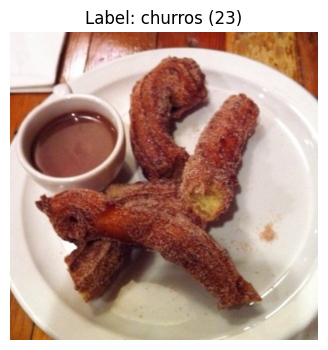

Image size: (512, 512)
Num classes: 101
Num training images: 75750


In [14]:
img, label = dataset[0]                                                                                                                                       
class_name = dataset.classes[label]                                                                                                                         
                                                                                                                                                            
plt.figure(figsize=(4, 4))                                                                                                                                    
plt.imshow(img)                                                                                                                                               
plt.title(f"Label: {class_name} ({label})")                                                                                                                   
plt.axis('off')                                                                                                                                               
plt.show()                                                                                                                                                    
                                                                                                                                                            
print(f"Image size: {img.size}")                                                                                                                              
print(f"Num classes: {len(dataset.classes)}")                                                                                                                 
print(f"Num training images: {len(dataset)}")      

In [7]:
from typing import Optional, Tuple

In [9]:
class SiglipVisionConfig:# we create a config so we can easily change sizes and configuration for vision encoders

    def __init__(
        self,
        hidden_size=768,# size of embedding vector
        intermediate_size=3072,# size of linear layer in feed forward
        num_hidden_layers=12, # num hidden in transformer
        num_attention_heads=12,# num heads
        num_channels=3,
        image_size=224,
        patch_size=16,# size of the patches. each patch will be 16x16
        layer_norm_eps=1e-6,
        attention_dropout=0.0,
        # we can use a single cls_token of the entire image, or we can use a list of embeddings that represent each patch.
        num_image_tokens: int = None,# how many output embeddings we expect. (how many image embeddings we have for each image.)
        **kwargs
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.num_channels = num_channels
        self.patch_size = patch_size
        self.image_size = image_size
        self.attention_dropout = attention_dropout
        self.layer_norm_eps = layer_norm_eps
        self.num_image_tokens = num_image_tokens

In [19]:
config = SiglipVisionConfig()

In [ ]:
class SiglipVisionEmbeddings(nn.Module):
    ## equivalent to PatchEmbedding in vit.py
    def __init__(self, config: SiglipVisionConfig):
        super().__init__()
        self.config = config
        self.embed_dim = config.hidden_size
        self.image_size = config.image_size
        self.patch_size = config.patch_size

        self.patch_embedding = nn.Conv2d(in_channels=3,
                                        out_channels = self.embed_dim,
                                        kernel_size = self.patch_size,
                                        stride = self.patch_size,# no overlap
                                        padding ='valid')#indicates no padding necessary
        
        self.num_patches =  int((self.image_size**2) / (self.patch_size**2))
        self.num_positions = self.num_patches
        # In our vit.py we used self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, num_hiddens))
        # these do the same thing, they create a laernable matrix of positional vectors.
        # under the hood, nn.Embedding is a wrapper for nn.PArameter with a lookup opertaion. 
        #nn.Embeddings is slightly more flexible, 
        self.position_embedding = nn.Embedding(self.num_positions, self.embed_dim)
        # remeber in vanilla transformer for text, we use sinusoidal positional embeddings
        # in this vision encoder, we let it learn the positinoal embedding. 
        # this is a vector the size of the patches.
        self.register_buffer(
            'position_ids',
            torch.arange(self.num_positions).expand((1, -1)),
            persistent=False
        )# this pre-creates an index tensor and stored it on the module so it moves to the right device. 
        #without it, we'd have to run   position_ids = torch.arange(num_positions, device=x.device) on the forward pass.                                                                                           
        
    def forward(self, pixel_values:torch.Tensor) -> torch.Tensor:
        _, _, height, width = pixel_values.shape #[Batch_Size, Channels, H, W] 
        # convolve the patch_size kernel over the image, no overlap
        # the ouput of the conv will have shape [Batch_Size, Embed_Dim, Num_Patches_H, Num_Pathces_W]
        patch_emeds = self.patch_embedding(pixel_values)
        
        embeddings = patch_emeds.flatten(2)# flatten to turn from grid to a flat vector. 
        #[Batch_Size, Embed_Dim, Num_Patches] -> [Batch_Size, Num_Patches, Embed_Dim]
        embeddings = embeddings.transpose(1, 2)
        embeddings = embeddings + self.position_embedding(self.position_ids)
        return embeddings

In [ ]:
import numpy as np
patcher = SiglipVisionEmbeddings(config)
t_image = torch.from_numpy(np.array(img)).unsqueeze(0).float() 
t_image = t_image.permute(0, 3, 1, 2)  # (B, H, W, C) → (B, C, H, W) 
resized = F.interpolate(t_image, size=(224, 224), mode='bilinear') 
out = patcher(resized )
out.shape #[Batch_Size, Num_Patches, Hidden_Dim]!!

torch.Size([1, 196, 768])

In [ ]:
class SiglipEncoder(nn.Module):
    def __init__(self, config: SiglipVisionConfig):
        self.config = config

    def forward(self, x):
        return x

In [ ]:
class SiglipVisionTransformer(nn.Module):

    def __init__(self, config: SiglipVisionConfig):
        super().__init__()
        self.config = config
        self.embed_dim = config.embed_dim

        self.embeddings = SiglipVisionEmbeddings(config) # this is equivalent to PatchEmbedding in our vit.py
        self.encoder = SiglipEncoder(config) # this is equivalent to TransformerEncoder in our vit.py
        self.post_layernorm = nn.LayerNorm(self.embed_dim, eps = config.layer_norm_eps)

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        # pixel_values: [Batch_Size, Channels, H, W] - > [Batch_Size, Num_PAtches, Embed_Size]
        hidden_states = self.embeddings(pixel_values)
        last_hidden_state = self.encoder(inputs_embeds = hidden_states)
        last_hidden_state = self.post_layernorm(last_hidden_state)
        return last_hidden_state

In [ ]:
class SiglipVisionModel(nn.Module):

    def __init__(self, config: SiglipVisionConfig):
         super().__init__()
         self.config = config
         self.vision_model =  SiglipVisionTransformer(config)

    def forward(self, pixel_values) -> Tuple:
         # [Batch_Size, Channels, H, W] -> [BAtch_Size, Num_Pathces, Embed_Dim]
         return self.vision_model(pixel_values = pixel_values)